#**Image processing using basic CNN**

> This notebook is part of my learning journey in deep learning fundamentals.
> Focus is on understanding concepts rather than achieving maximum accuracy.

# Objective

This notebook aims to demonstrate the process of building and evaluating a Convolutional Neural Network (CNN) for image classification using **<font color=cyan>TensorFlow</font>**. Specifically, I have used MNIST dataset from **<font color=cyan>keras</font>** library, which consists of handwritten digits. The key steps covered include data loading, pre-processing, CNN model definition using various layers like `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense`, training, and evaluation.

#**Importing Libraries**

In [ ]:
import tensorflow as tf
from keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#**<font color='red'>1.</font> Loading Dataset**

In [ ]:
# Splitting the data into training and testing sets
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (60000, 28, 28)
y_train.shape: (60000,)
X_test.shape: (10000, 28, 28)
y_test.shape: (10000,)


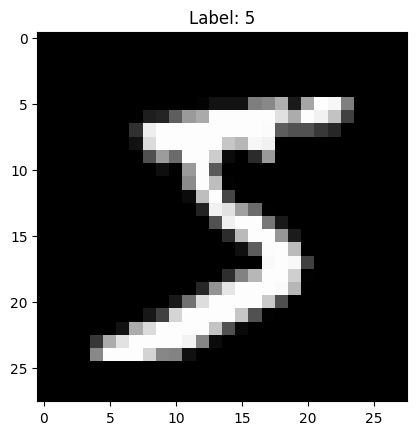

In [ ]:
# Sample image
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

#**<font color='red'>2.</font> Pre-processing**

In [ ]:
# Normalizing the data (based on number of possible pixel values)
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
# Adding a new axis as CNN expects image format to have channel count as well (height, width, channels)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print(f"X_train shape : {X_train.shape}")

X_train shape : (60000, 28, 28, 1)


#**<font color='red'>3.</font> Train the CNN model**

In [ ]:
# Define the CNN model with its layers
cnn = models.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        86,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,050 (340.04 KB)

 Trainable params: 87,050 (340.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training/fitting the model
# using training datsets
training_history = cnn.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9394 - loss: 0.2097 - val_accuracy: 0.9807 - val_loss: 0.0786
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9786 - loss: 0.0701 - val_accuracy: 0.9840 - val_loss: 0.0594
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9846 - loss: 0.0507 - val_accuracy: 0.9833 - val_loss: 0.0628
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9876 - loss: 0.0398 - val_accuracy: 0.9848 - val_loss: 0.0609
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9903 - loss: 0.0308 - val_accuracy: 0.9878 - val_loss: 0.0535


#**<font color='red'>4.</font> Evaluate the CNN model**

In [ ]:
test_loss, test_acc = cnn.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9825 - loss: 0.0526
Test accuracy: 0.9825000166893005


#**Training accuracy Vs Validation Accuracy Vs Test Accuracy**

In [ ]:
# Preparing data to plot
epochs = range(1, len(training_history.history['accuracy']) + 1)
training_accuracies = [round(accuracy * 100, 3) for accuracy in training_history.history['accuracy']]
validation_accuracies = [round(accuracy * 100, 3) for accuracy in training_history.history['val_accuracy']]
test_accuracies = [round(test_acc * 100, 3)] * len(epochs)

data = pd.DataFrame({
    'Epoch': epochs,
    'Training Accuracy': training_accuracies,
    'Validation Accuracy': validation_accuracies,
    'Test_Accuracy': test_accuracies
})

data = data.melt(id_vars='Epoch', var_name='Dataset', value_name='Accuracy')

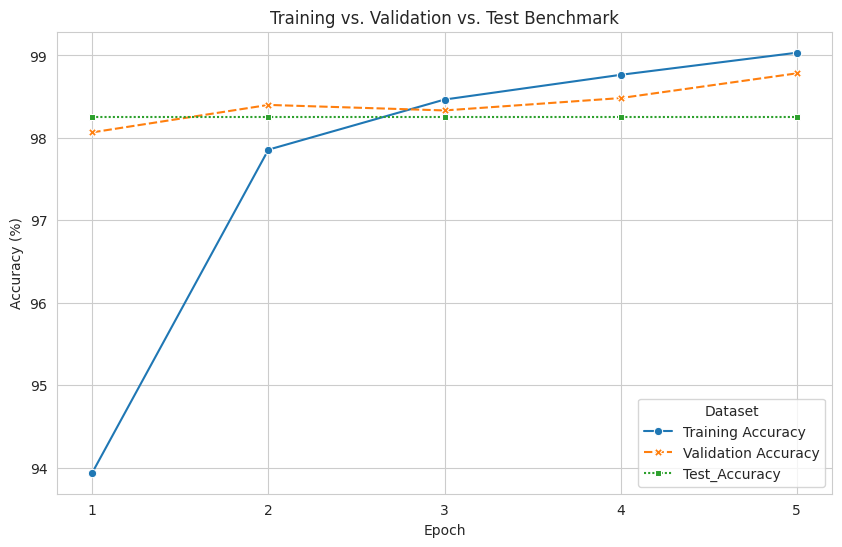

In [ ]:
# Plot all accuracies
plt.figure(figsize=(10, 6))
plt.xlabel('Epoch')
plt.xticks(epochs)
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation vs. Test Benchmark')
sns.set_style("whitegrid")

sns.lineplot(data=data, x='Epoch', y='Accuracy', hue='Dataset', style='Dataset', markers=True)

plt.show()